<a href="https://colab.research.google.com/github/TeachFeastKunal/ML-Learning-2026/blob/main/car_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
!pip install -q kaggle

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
import os
from google.colab import userdata
import kagglehub

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [64]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")


In [65]:
csv_path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")
csv_file = os.listdir(csv_path)[0]

Using Colab cache for faster access to the 'car-price-predictionused-cars' dataset.


In [66]:
df = pd.read_csv(os.path.join(csv_path , csv_file))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [67]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [68]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [69]:
# Calculating null values in df

df[df.isna()].count()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


<Axes: xlabel='Selling_type', ylabel='Count'>

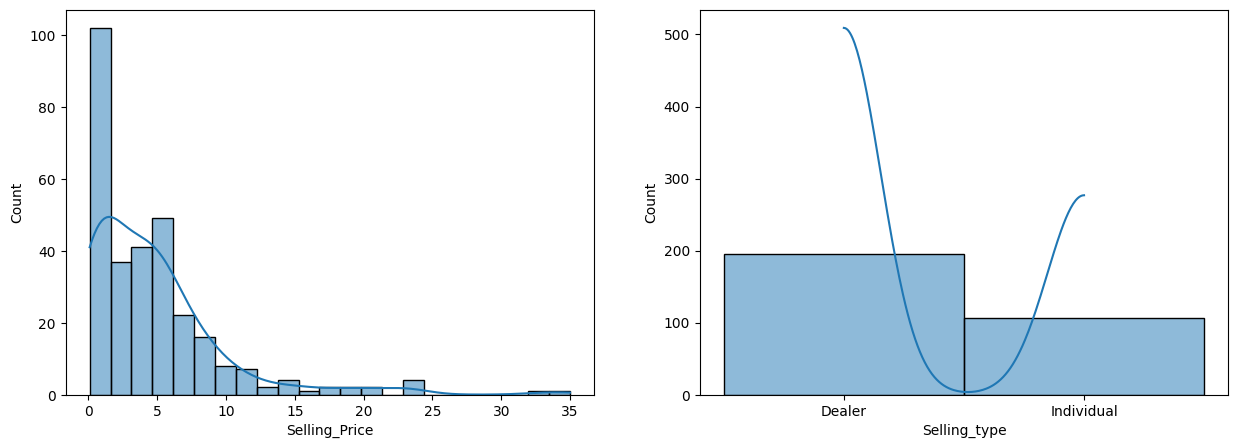

In [70]:
fig , axs = plt.subplots(1 , 2 , figsize = (15 ,5))
sns.histplot(ax = axs[0] , data = df, x= "Selling_Price" ,  kde = True ) # large number of cheap cars in the range of 0 to 6
sns.histplot(ax = axs[1] , data = df, x= "Selling_type" ,  kde = True ) # many were sold through dealership almost twice than the amount of individually sold

<Axes: ylabel='Present_Price'>

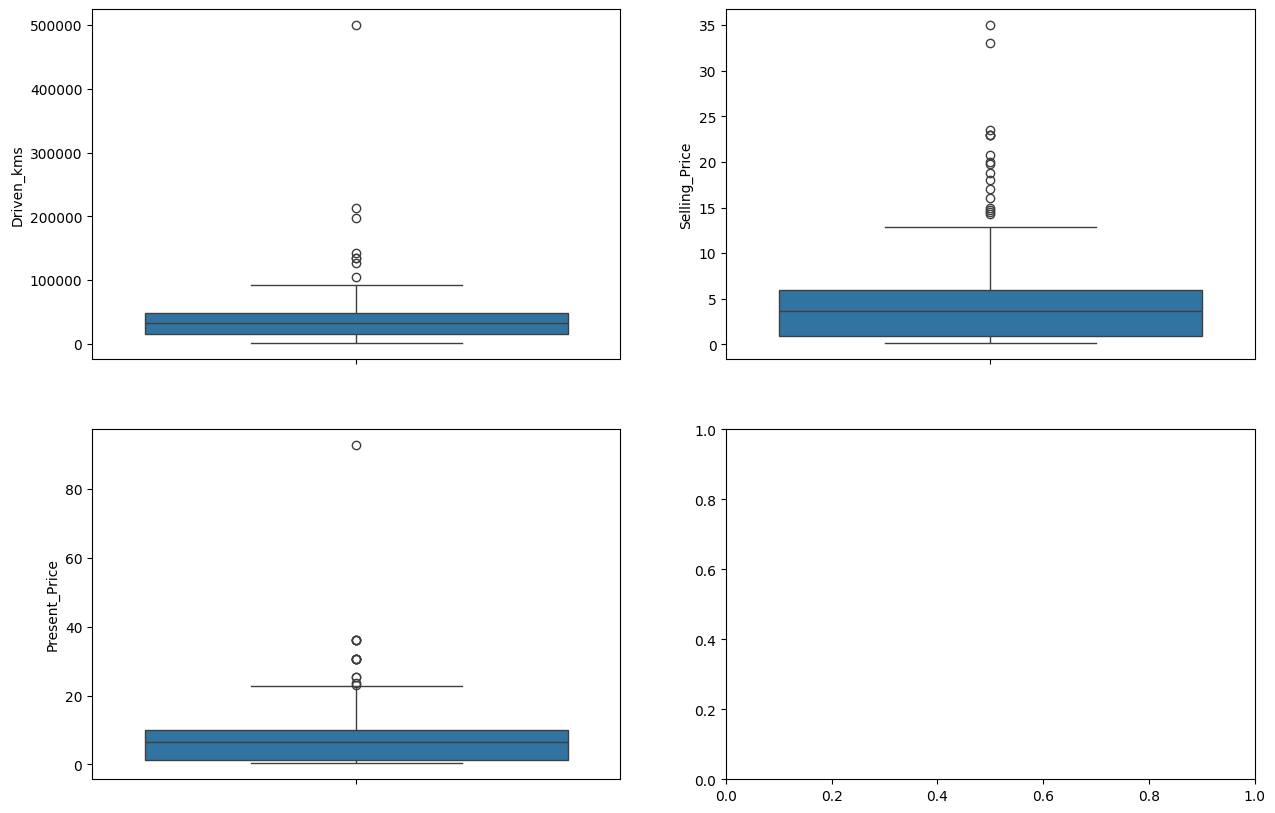

In [71]:
fig , axs = plt.subplots(2,2 , figsize = (15 , 10))
sns.boxplot(ax = axs[0,0] , data = df, y= "Driven_kms" ) # all the three have extreme outliers
sns.boxplot(ax = axs[0,1] , data = df, y= "Selling_Price" ) # selling price ranges from 0 to 12.5
sns.boxplot(ax = axs[1,0] , data = df, y= "Present_Price" ) # present price ranges between 0 and 21

## Bivariate Analysis


<Axes: xlabel='Present_Price', ylabel='Selling_Price'>

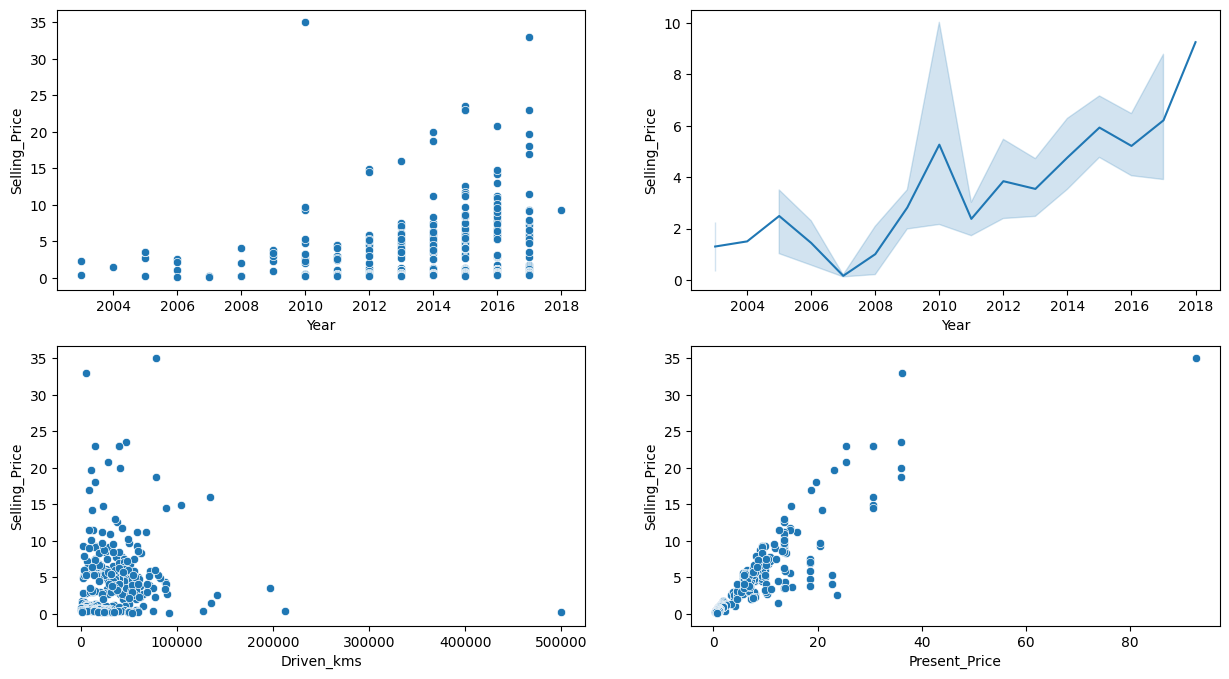

In [73]:
fig , axs = plt.subplots(2 , 2 , figsize = (15 ,8))

sns.scatterplot(ax = axs[0,0] , data = df , x = "Year" , y = "Selling_Price") # selling price increased with every year
sns.lineplot(ax = axs[0,1] , data = df , x = "Year" , y = "Selling_Price" )
sns.scatterplot(ax = axs[1,0] , data = df , x = "Driven_kms" , y = "Selling_Price") # akmost all cars are driven under 1L km , low mileage have high price
sns.scatterplot(ax = axs[1,1] , data = df , x = "Present_Price" , y = "Selling_Price") # selling price always less than present price

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
85,camry,2006,2.5,23.73,142000,Petrol,Individual,Automatic,3


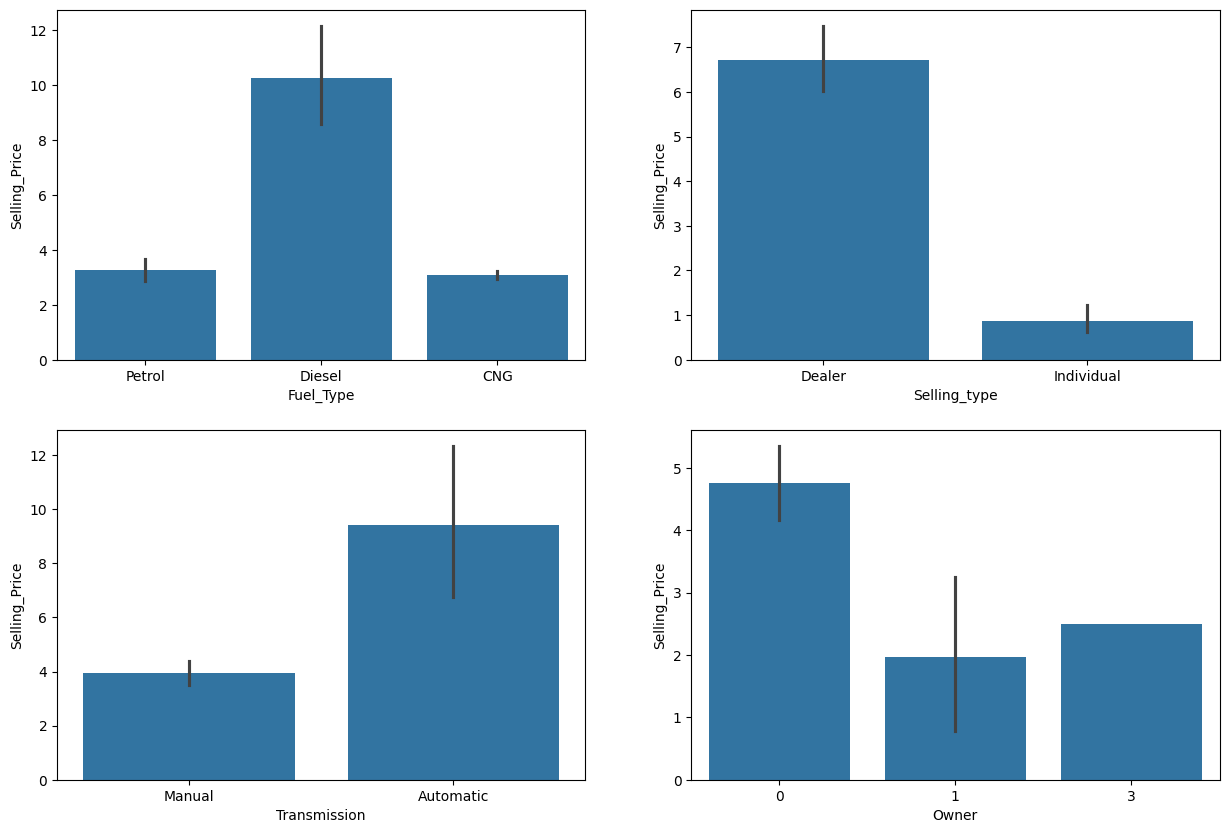

In [74]:
fig , axs = plt.subplots(2 , 2 , figsize = (15 ,10))

sns.barplot(ax = axs[0,0] , data = df , x = "Fuel_Type" , y = "Selling_Price") # diesel cars have higher price and variation in it in comparison to petrol and cng
sns.barplot(ax = axs[0,1] , data = df , x = "Selling_type" , y = "Selling_Price") # Similarly car sold through dealership are priced higher and more variation in rate
sns.barplot(ax = axs[1,0] , data = df , x = "Transmission" , y = "Selling_Price") # AUtomatic cars have higher selling rate and the price vary greatly
sns.barplot(ax = axs[1,1] , data = df , x = "Owner" , y = "Selling_Price") # higher price cause for new vehicles then used ones and owner 3 having highes selling price in comparison to owner 1 and no wick suggests there is only one car
df[df["Owner"] == 3]  # can be seen here only 1 car with 3 owners

## Feature Engineering And Preprocessing

In [75]:
df.columns.to_series().reset_index(drop = True)
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [76]:
from datetime import date
df["Car_Age"] = date.today().year - df["Year"]

In [77]:
df.drop(["Year"] , axis =1 , inplace= True)
df.drop(["Car_Name"] , axis =1 , inplace= True)
df = df[~(df['Selling_Price'] >= 30)]

In [79]:
from sklearn.model_selection import train_test_split

df_encoded = pd.get_dummies(df ,  ["Fuel_Type" , "Selling_type" , "Transmission"] , dtype = int , drop_first = True)

Y = df_encoded["Selling_Price"]
X = df_encoded.drop(["Selling_Price"] , axis = 1)

x_train , x_test , y_train , y_test = train_test_split(X , Y , test_size= 0.2 , random_state = 42 , shuffle = True)



## Linear Regression

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error , root_mean_squared_error

lr_model = LinearRegression()
lr_model.fit(x_train , y_train)

lr_pred = lr_model.predict(x_test)

r_sq = r2_score(y_test , lr_pred)
mae = mean_absolute_error(y_test , lr_pred)
rmse = root_mean_squared_error(y_test , lr_pred)

print(r_sq)
print(mae)
print(rmse)


0.8488707839193155
1.2163740193330348
1.8658375680942367


## Random Forest Regressor

In [81]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(x_train , y_train)

rf_pred = rf_model.predict(x_test)

rf_r_sq = r2_score(y_test , rf_pred)
rf_mae = mean_absolute_error(y_test , rf_pred)
rf_rmse = root_mean_squared_error(y_test , rf_pred)

print(rf_r_sq)
print(rf_mae)
print(rf_rmse)

0.9595203313222208
0.6408918032786887
0.9656463271717692


##### Hyperparameter Tuning

In [82]:
from sklearn.model_selection import GridSearchCV

rf_grid_param = {
    "n_estimators" : [50 , 100 , 200],
    "max_depth" : [None , 5 , 10 , 15],
    "min_samples_split" : [2 , 5 , 10]
}

rf_grid = GridSearchCV(estimator = RandomForestRegressor(random_state = 42) , param_grid= rf_grid_param , scoring= "r2" , cv = 5 , n_jobs = -1)
rf_grid.fit(x_train , y_train)

best_rf_model = rf_grid.best_estimator_

print(rf_grid.best_params_)
print(rf_grid.best_score_)
print(best_rf_model)


{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
0.8880720186968436
RandomForestRegressor(max_depth=10, random_state=42)


In [83]:
best_rf_model_pred = best_rf_model.predict(x_test)

best_rf_model_r_sq = r2_score(y_test , best_rf_model_pred)
best_rf_model_mae = mean_absolute_error(y_test , best_rf_model_pred)
best_rf_model_rmse = root_mean_squared_error(y_test , best_rf_model_pred)

print(best_rf_model_r_sq)
print(best_rf_model_mae)
print(best_rf_model_rmse)

0.9608651282103172
0.6308173347423596
0.9494707192967881


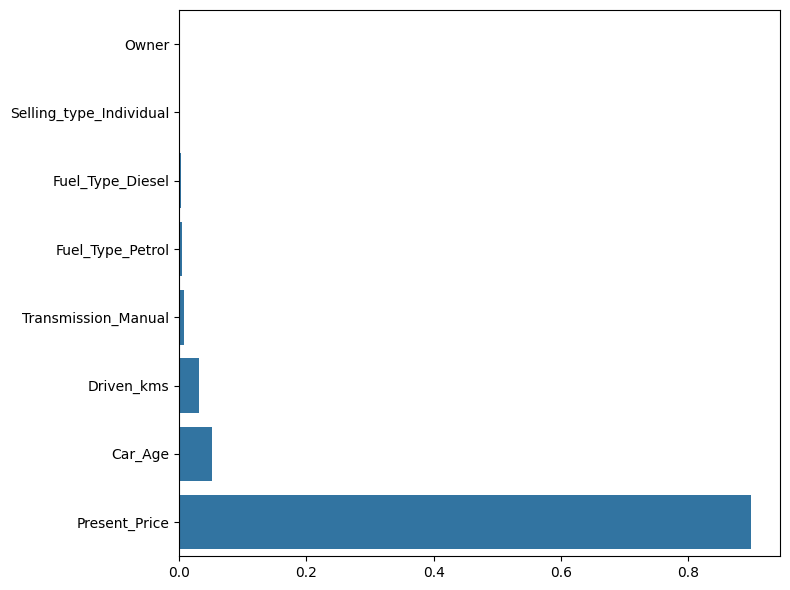

In [84]:
import numpy as np

importances = rf_model.feature_importances_
feature_name = X.columns
indices = np.argsort(importances)
sorted_features = [feature_name[i] for i in indices]
sorted_importances = importances[indices]

fig , axs = plt.subplots(1 ,1 , figsize = (8 , 6))
sns.barplot(ax = axs , x = sorted_importances , y = sorted_features )
plt.tight_layout()
plt.show()

## XGBOOST Regressor

In [85]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor()
xgb_model.fit(x_train , y_train)

XGB_pred = xgb_model.predict(x_test)

XGB_r_sq = r2_score(y_test , XGB_pred)
XGB_mae = mean_absolute_error(y_test , XGB_pred)
XGB_rmse = root_mean_squared_error(y_test , XGB_pred)

print(XGB_r_sq)
print(XGB_mae)
print(XGB_rmse)

0.9524390988260215
0.6199078035745463
1.0467058607146293


##### Hyperparameter Tuning

In [86]:
XGB_grid_param = {
    "learning_rate" : [0.01 , 0.05 , 0.1]
}

XGB_Grid = GridSearchCV(estimator= XGBRegressor(random_state = 42) , param_grid = XGB_grid_param , scoring= "r2" , cv = 5 , n_jobs = -1)
XGB_Grid.fit(x_train , y_train)

best_XGB_Model = XGB_Grid.best_estimator_

print(XGB_Grid.best_score_)
print(XGB_Grid.best_params_)
print(best_XGB_Model)

0.9134728847976238
{'learning_rate': 0.1}
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [87]:
best_XGB_Model_pred = best_XGB_Model.predict(x_test)

best_XGB_model_r_sq = r2_score(y_test , best_XGB_Model_pred)
best_XGB_model_mae = mean_absolute_error(y_test , best_XGB_Model_pred)
best_XGB_model_rmse = root_mean_squared_error(y_test , best_XGB_Model_pred)

print(best_XGB_model_r_sq)
print(best_XGB_model_mae)
print(best_XGB_model_rmse)

0.947755953150303
0.6443579712461253
1.0970287858065526


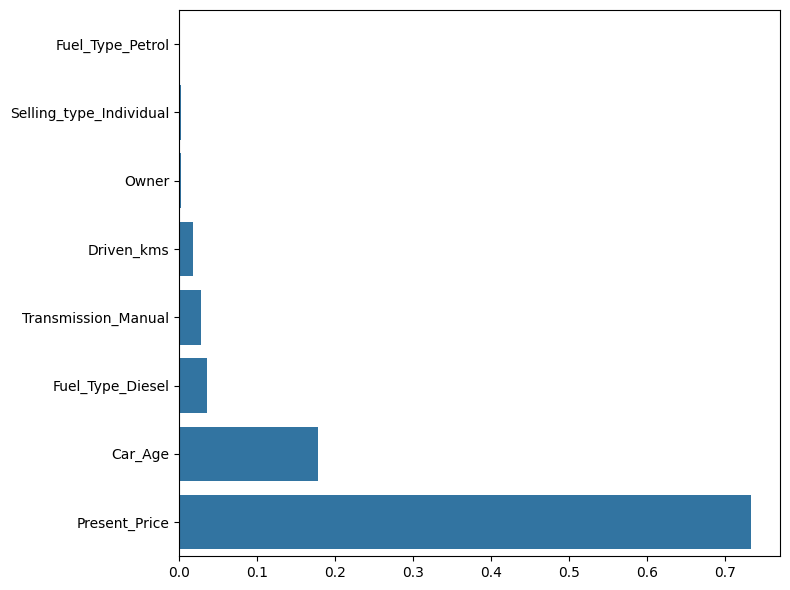

In [88]:
XGB_importances = xgb_model.feature_importances_
feature_name = X.columns
indices = np.argsort(XGB_importances)

sortedXGB_features = [feature_name[i] for i in indices]
sortedXGB_importances = XGB_importances[indices]

fig , axss = plt.subplots(1 ,1 , figsize = (8 , 6))
sns.barplot(ax = axss , x = sortedXGB_importances , y = sortedXGB_features )
plt.tight_layout()
plt.show()


## Final Result Table

In [105]:
data = {
    "Model" : ["Linear Regression" , "Random Forest Regression" , "XGBoost Regression"] ,
    "R2 Score" : [r_sq , rf_r_sq , XGB_r_sq] ,
    "MAE" : [mae , rf_mae , XGB_mae] ,
    "RMSE" : [rmse , rf_rmse , XGB_rmse]
}
hyper_tuned_models =  {
    "Hypertuned Model" : ["Linear Regression" , "Random Forest Regression" , "XGBoost Regression"] ,
    "R2 Score" : [r_sq , best_rf_model_r_sq , best_XGB_model_r_sq] ,
    "MAE" : [mae , best_rf_model_mae , best_XGB_model_mae] ,
    "RMSE" : [rmse , best_rf_model_rmse , best_XGB_model_rmse]
}

result_df = pd.DataFrame(data).sort_values(by = "R2 Score" , ascending = True)
HyperTuned_result_df = pd.DataFrame(hyper_tuned_models).sort_values(by = "R2 Score" , ascending = True)

print(result_df , "\n")
print("-----------------------------------------------------------------\n")
print(HyperTuned_result_df)

                      Model  R2 Score       MAE      RMSE
0         Linear Regression  0.848871  1.216374  1.865838
2        XGBoost Regression  0.952439  0.619908  1.046706
1  Random Forest Regression  0.959520  0.640892  0.965646 

-----------------------------------------------------------------

           Hypertuned Model  R2 Score       MAE      RMSE
0         Linear Regression  0.848871  1.216374  1.865838
2        XGBoost Regression  0.947756  0.644358  1.097029
1  Random Forest Regression  0.960865  0.630817  0.949471






## 🏁 Conclusion & Next Steps

### Summary of Performance
* Our best-performing model (**Hypertuned Random Forest**) explains **~96.1%** of the variance in car prices ($R^2 = 0.9609$).
* On average, our final predictions deviate from the true resale value by an error of **~₹63,081** (MAE = 0.6308) and an RMSE of **~₹94,947** (RMSE = 0.9495).
* While baseline **Linear Regression** provided a solid foundation ($R^2 = 0.8489$), ensemble tree-based models handled the non-linear impacts of depreciation and luxury categories significantly better.
* Interestingly, basic hyperparameter tuning slightly over-corrected **XGBoost** ($R^2$ dropped from 0.9524 to 0.9478), but it successfully optimized our **Random Forest** to its peak predictive accuracy.

### What to Improve Next
1. **Scraping More High-Owner Data**: Grouping columns like `Owner` suffered from small sample sizes. Gathering more data on multi-owner vehicles would eliminate statistical noise.
2. **Advanced Text Mining on Car_Name**: Instead of dropping `Car_Name` due to its inconsistent formatting, we could use a custom dictionary to extract specific vehicle body types (e.g., SUV, Hatchback, Sedan, or Two-Wheeler) to give the model structural context.
3. **Incorporate Macro Features**: Adding external economic features like historical fuel price spikes or regional demand data would help the model map changing consumer preferences over time.
